In [ ]:
%%capture
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

import torch
from packaging.version import Version as V

xformers_version = "xformers==0.0.27.post2" if V(torch.__version__) < V("2.4.0") else "xformers"
!pip install --no-deps {xformers_version} trl peft accelerate bitsandbytes triton

In [ ]:
import numpy as np
import os
import unsloth
import torch
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

from tqdm.auto import tqdm

print("Unsloth version:", unsloth.__version__)
print("Torch version:", torch.__version__)
!python -m xformers.info

Unsloth version: 2026.7.2
Torch version: 2.11.0+cu128
xFormers 0.0.35
memory_efficient_attention.ckF:                    unavailable
memory_efficient_attention.ckB:                    unavailable
memory_efficient_attention.ck_splitKF:             unavailable
memory_efficient_attention.cutlassF-pt:            available
memory_efficient_attention.cutlassB-pt:            available
memory_efficient_attention.cutlassF-blackwell:     unavailable
memory_efficient_attention.cutlassB-blackwell:     unavailable
memory_efficient_attention.fa2F@2.5.7-pt:          available
memory_efficient_attention.fa2B@2.5.7-pt:          available
memory_efficient_attention.fa3F@0.0.0:             unavailable
memory_efficient_attention.fa3B@0.0.0:             unavailable
memory_efficient_attention.fa3F_splitKV@0.0.0:     unavailable
memory_efficient_attention.triton_splitKF:         available
indexing.scaled_index_addF:                        unavailable
indexing.scaled_index_addB:                        unavail

## Configuration

All paths and hyperparameters live here so you only need to edit one place.

In [ ]:
DRIVE_DIR = "/content/drive/MyDrive/EDLLM"
TRAIN_FILE = "fitness_llm_train.jsonl"
VAL_FILE = "fitness_llm_val.jsonl"


BASE_MODEL = "unsloth/Qwen3-8B"
MAX_SEQ_LENGTH = 2048

#  LoRA
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

OUTPUT_DIR = "qwen_health_model"
MAX_STEPS = 500
LEARNING_RATE = 5e-5


LORA_SAVE_DIR = "qwen3_health_lora"
MERGED_SAVE_DIR = "qwen3_health_merged"
GGUF_SAVE_DIR = "qwen3_health_gguf"
GGUF_QUANT_METHOD = "Q4_K_S"

## Load base model and attach LoRA

In [ ]:
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
)

==((====))==  Unsloth 2026.7.2: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=TARGET_MODULES,
    use_gradient_checkpointing="unsloth",
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.7.2 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


## Load data from Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

train_dataset = load_dataset("json", data_files=f"{DRIVE_DIR}/{TRAIN_FILE}", split="train")
val_dataset = load_dataset("json", data_files=f"{DRIVE_DIR}/{VAL_FILE}", split="train")

print(f"Train examples: {len(train_dataset)}")
print(f"Val examples:   {len(val_dataset)}")

Mounted at /content/drive


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Train examples: 2032
Val examples:   227


In [ ]:
#Converting chat-formatted 'messages' into a single 'text' field for SFTTrainer.
def add_text_field(examples):
    texts = [
        tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        for messages in examples["messages"]
    ]
    return {"text": texts}

train_dataset = train_dataset.map(add_text_field, batched=True)
val_dataset = val_dataset.map(add_text_field, batched=True)

print(train_dataset[0]["text"][:300])

Map:   0%|          | 0/2032 [00:00<?, ? examples/s]

Map:   0%|          | 0/227 [00:00<?, ? examples/s]

<|im_start|>system
You are a friendly, supportive fitness safety advisor. You help people make safe, well-informed decisions about outdoor physical activity, using their personal health profile, their planned workout, and the risk level you are given for today.

## Interaction style
- Be warm and di


In [ ]:
def save_metrics_to_file():
    """Save metrics to JSON for later analysis."""
    import os  
    import json  
    metrics_path = os.path.join(OUTPUT_DIR, "metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(loss_history, f, indent=2)
    print(f" Metrics saved to {metrics_path}")

## Train

In [ ]:
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=LEARNING_RATE,           
        warmup_ratio=0.1,
        max_steps=500,                         
        fp16=True,
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=50,                        
        output_dir=OUTPUT_DIR,
        optim="adamw_8bit",
        report_to="none",
        save_strategy="no",
    ),
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/2032 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/227 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🚀 Starting training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,032 | Num Epochs = 2 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 21,823,488 of 8,212,558,848 (0.27% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
50,1.743360,1.313311
100,0.152122,0.144163
150,0.108115,0.098770
200,0.077246,0.074295
250,0.060219,0.055058
300,0.040955,0.044024
350,0.036968,0.037842
400,0.030919,0.032333
450,0.028861,0.029242
500,0.026135,0.028116


✅ Metrics saved to qwen_health_model/metrics.json
✅ Metrics saved to qwen_health_model/metrics.json
✅ Metrics saved to qwen_health_model/metrics.json


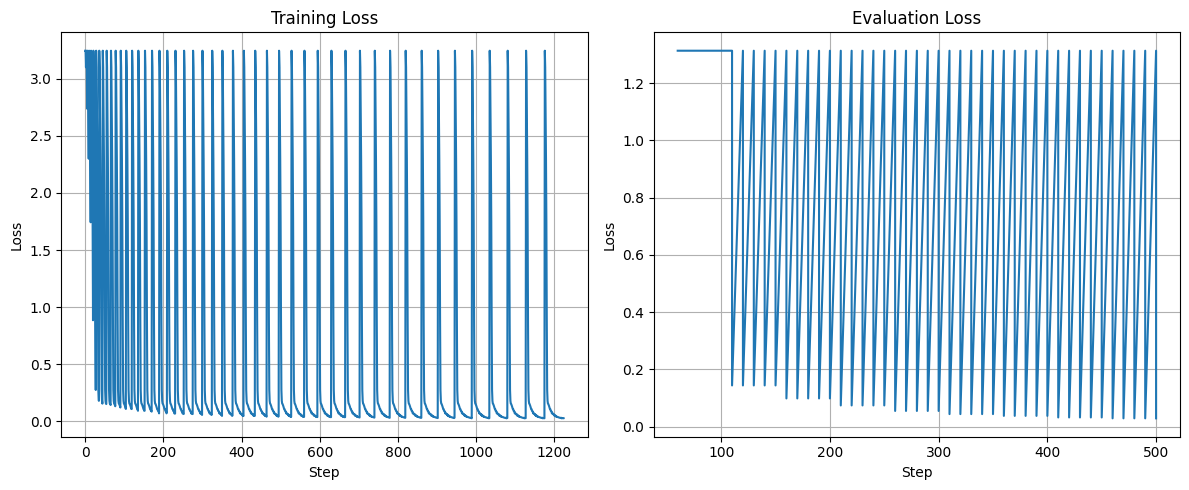

📊 Loss curves saved to qwen_health_model/loss_curves.png

📊 FINAL TRAINING METRICS
📉 Training Loss (final): 0.0282
📉 Training Loss (min): 0.0268
📈 Training Loss (avg): 0.6109
📊 Evaluation Loss (final): 0.0292
📊 Evaluation Loss (min): 0.0292
📈 Perplexity (final): 1.03
📈 Perplexity (min): 1.03


In [ ]:
# ─── VALIDATION & METRIC TRACKING ──────────────────────────────────────────────

import matplotlib.pyplot as plt
import json

# ─── 1. Track loss history ──────────────────────────────────────────────────────
loss_history = {
    "train_loss": [],
    "eval_loss": [],
    "eval_steps": [],
    "perplexity": [],
}

def log_metrics(trainer, step):
    """Log training and evaluation metrics to a file."""
    try:
        # Get training loss from trainer state
        if hasattr(trainer, "state") and trainer.state.log_history:
            logs = trainer.state.log_history
            for log in logs:
                if "loss" in log and "eval_loss" not in log:
                    loss_history["train_loss"].append(log["loss"])
                elif "eval_loss" in log:
                    loss_history["eval_loss"].append(log["eval_loss"])
                    loss_history["eval_steps"].append(step)
                    if "eval_loss" in log and log["eval_loss"] > 0:
                        perplexity = np.exp(log["eval_loss"])
                        loss_history["perplexity"].append(perplexity)
    except Exception as e:
        print(f"⚠️ Logging metrics failed: {e}")

# def save_metrics_to_file():
#     """Save metrics to JSON for later analysis."""
#     metrics_path = os.path.join(OUTPUT_DIR, "metrics.json")
#     with open(metrics_path, "w") as f:
#         json.dump(loss_history, f, indent=2)
#     print(f"💾 Metrics saved to {metrics_path}")

# ─── 2. Callback for saving metrics at each step ──────────────────────────────
from transformers import TrainerCallback

class MetricsCallback(TrainerCallback):
    def on_step_end(self, args, state, control, **kwargs):
        """Log metrics at the end of each step."""
        if state.global_step % 10 == 0:  # Log every 10 steps
            log_metrics(trainer, state.global_step)

    def on_epoch_end(self, args, state, control, **kwargs):
        save_metrics_to_file()

# ─── 3. Add callback to trainer ──────────────────────────────────────────────────
trainer.add_callback(MetricsCallback())

# ─── 4. Plot loss curves ──────────────────────────────────────────────────────
def plot_loss_curves():
    """Generate and save loss curves."""
    if not loss_history["train_loss"]:
        print("⚠️ No loss data to plot")
        return

    plt.figure(figsize=(12, 5))

    # Training loss
    plt.subplot(1, 2, 1)
    plt.plot(loss_history["train_loss"])
    plt.title("Training Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True)

    # Evaluation loss
    plt.subplot(1, 2, 2)
    if loss_history["eval_loss"]:
        plt.plot(loss_history["eval_steps"], loss_history["eval_loss"])
        plt.title("Evaluation Loss")
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "loss_curves.png"), dpi=150)
    plt.show()
    print(f"📊 Loss curves saved to {OUTPUT_DIR}/loss_curves.png")

# ─── 5. Run training ──────────────────────────────────────────────────────────
print("🚀 Starting training...")
trainer.train()

# ─── 6. Save final metrics ─────────────────────────────────────────────────────
save_metrics_to_file()
plot_loss_curves()

# ─── 7. Print final metrics ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("📊 FINAL TRAINING METRICS")
print("=" * 60)

if loss_history["train_loss"]:
    train_losses = loss_history["train_loss"]
    print(f"📉 Training Loss (final): {train_losses[-1]:.4f}")
    print(f"📉 Training Loss (min): {min(train_losses):.4f}")
    print(f"📈 Training Loss (avg): {sum(train_losses)/len(train_losses):.4f}")

if loss_history["eval_loss"]:
    eval_losses = loss_history["eval_loss"]
    print(f"📊 Evaluation Loss (final): {eval_losses[-1]:.4f}")
    print(f"📊 Evaluation Loss (min): {min(eval_losses):.4f}")
    print(f"📈 Perplexity (final): {loss_history['perplexity'][-1]:.2f}")
    print(f"📈 Perplexity (min): {min(loss_history['perplexity']):.2f}")

In [ ]:
import os

OUTPUT_DIR = "qwen_health_model"

# Check what's in the output directory
print("📁 Contents of output directory:")
for root, dirs, files in os.walk(OUTPUT_DIR):
    print(f"\n📂 {root}")
    for d in dirs:
        print(f"  📁 {d}/")
    for f in files[:5]:  # Show first 5 files
        print(f"  📄 {f}")
    if len(files) > 5:
        print(f"  ... and {len(files)-5} more files")

📁 Contents of output directory:

📂 qwen_health_model
  📄 metrics.json
  📄 loss_curves.png


## Save and export the model

In [ ]:
# LoRA adapter only 
model.save_pretrained(LORA_SAVE_DIR)
tokenizer.save_pretrained(LORA_SAVE_DIR)

# Full merged 16-bit model (base weights + LoRA combined)
model.save_pretrained_merged(MERGED_SAVE_DIR, tokenizer)

print("✅ Saved LoRA adapter to:", LORA_SAVE_DIR)
print("✅ Saved merged model to:", MERGED_SAVE_DIR)

Unsloth: Restored added_tokens_decoder metadata in qwen3_health_lora/tokenizer_config.json.


config.json:   0%|          | 0.00/754 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/32.9k [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in qwen3_health_merged/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.58G [00:00<?, ?B/s]


Unsloth: Preparing safetensor model files: 100%|██████████| 4/4 [13:34<00:00, 203.58s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [04:52<00:00, 73.02s/it]


Unsloth: Merge process complete. Saved to `/content/qwen3_health_merged`
✅ Saved LoRA adapter to: qwen3_health_lora
✅ Saved merged model to: qwen3_health_merged


In [ ]:
# GGUF export — this can be called directly on the trained model, Unsloth
model.save_pretrained_gguf(
    GGUF_SAVE_DIR,
    tokenizer,
    quantization_method=GGUF_QUANT_METHOD,
)
print("✅ GGUF conversion complete!")

Unsloth: Merging model weights to 16-bit format...


Unsloth: Restored added_tokens_decoder metadata in qwen3_health_gguf/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00004.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.58G [00:00<?, ?B/s]


Unsloth: Preparing safetensor model files: 100%|██████████| 4/4 [13:29<00:00, 202.29s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)



Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [04:56<00:00, 74.11s/it]


Unsloth: Merge process complete. Saved to `/content/qwen3_health_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_s'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Installing prebuilt llama.cpp b9975-mix-53618c5 (app-b9975-mix-53618c5-linux-x64-cpu.tar.gz) - skipping compilation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['qwen3_health_gguf_gguf/qwen3-8b.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_s. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfu

## Copy everything to Google Drive

In [ ]:
# JUST SAVE THIS - all you need for local inference
import glob
import os
import shutil

os.makedirs(DRIVE_DIR, exist_ok=True)

gguf_files = glob.glob(f"{GGUF_SAVE_DIR}/*.gguf") + glob.glob(f"{GGUF_SAVE_DIR}*/*.gguf")
if gguf_files:
    for f in gguf_files:
        dst = f"{DRIVE_DIR}/{os.path.basename(f)}"
        shutil.copy(f, dst)
        print(f"✅ Copied GGUF file: {f} → {dst}")

print(f"\n📁 Saved GGUF model to {DRIVE_DIR}")
!ls -lh {DRIVE_DIR}/*.gguf

✅ Copied GGUF file: qwen3_health_gguf_gguf/qwen3-8b.Q4_K_S.gguf → /content/drive/MyDrive/EDLLM/qwen3-8b.Q4_K_S.gguf

📁 Saved GGUF model to /content/drive/MyDrive/EDLLM
-rw------- 1 root root 4.5G Jul 13 12:35 /content/drive/MyDrive/EDLLM/qwen3-8b.Q4_K_S.gguf


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
